# Import Libraries and Set Constants
Import required libraries including pandas, numpy, plotly, and define constants like file paths and CTD parameters mapping.

In [92]:
# Import Libraries and Set Constants

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Define constants£
# Define file paths
idronaut_file= [r"../data\Level2\Forel-GroupedStn\20240703_1346_idronaut_downward.csv", 
                r"../data\Level2\Forel-GroupedStn\20240707_1658_idronaut_downward.csv",
                r"../data\Level2\Forel-GroupedStn\20240708_1337_idronaut_downward.csv"]
seabird_file = [
    r"../data/Level2/Forel-GroupedStn/2024-07-03T050545 SBE0251267_downward.csv", 
                    r"../data/Level2/Forel-GroupedStn/2024-07-07T094429 SBE0251267_downward.csv",
                    r"../data/Level2/Forel-GroupedStn/2024-07-08T025539 SBE0251267_downward.csv"
]
df_seabird = pd.concat([pd.read_csv(f) for f in seabird_file])
#Open file, print column names
df_idronaut = pd.concat([pd.read_csv(f) for f in idronaut_file])


In [93]:
#Filter both dataframe at depth > 50
df_seabird = df_seabird[(df_seabird['depth_m'] > 5) & (df_seabird['depth_m'] < 13)]
df_idronaut = df_idronaut[(df_idronaut['depth_m'] > 5) & (df_idronaut['depth_m'] < 13)]

In [95]:
df_idronaut.to_excel("df_idronaut_formatted.xlsx", index=False)
df_seabird.to_excel("df_seabird_formatted.xlsx", index=False)

<Axes: >

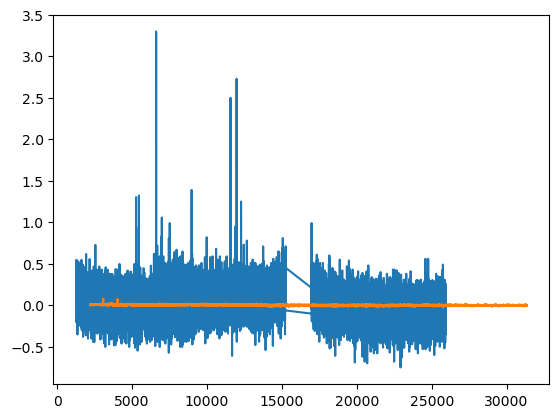

In [90]:
df_idronaut = df_idronaut[df_idronaut['depth_m'] > 50]
df_idronaut['Chl(a)Phy-EthrinPhy-Cyanin'].plot()

df_seabird = df_seabird[df_seabird['depth_m'] > 50]
df_seabird['fluorescence_mg_m3'].plot()
#Adapt y axis to max 0.5

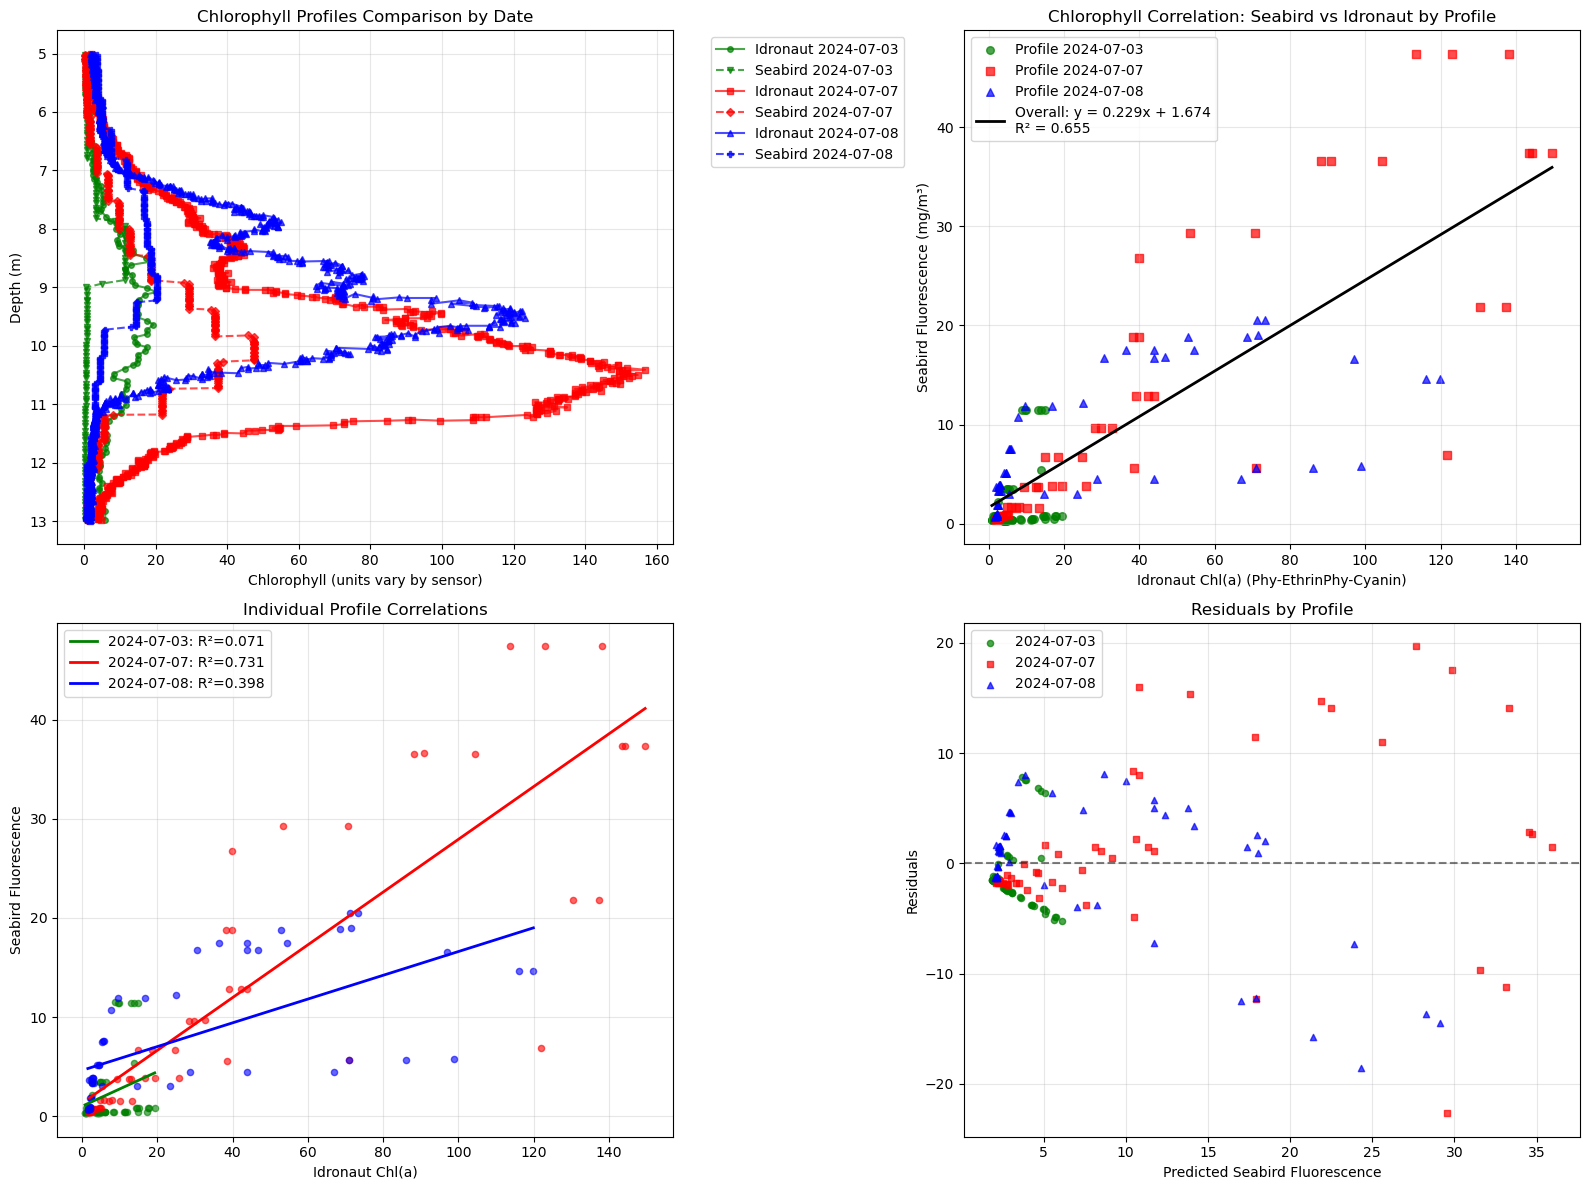

=== OVERALL CHLOROPHYLL CORRELATION ANALYSIS ===
Correlation coefficient (r): 0.8093
R-squared (R²): 0.6550
P-value: 5.05e-36
Standard error: 0.0137

=== OVERALL LINEAR REGRESSION EQUATION ===
Seabird_Fluorescence = 0.2290 × Idronaut_Chl + 1.6744

=== INDIVIDUAL PROFILE STATISTICS ===
2024-07-03: R²=0.071, y = 0.174x + 1.027
2024-07-07: R²=0.731, y = 0.266x + 1.342
2024-07-08: R²=0.398, y = 0.120x + 4.642

=== OVERALL CORRELATION ASSESSMENT ===
Correlation strength: Strong
Total data points used: 150

=== UNIT CONVERSION EXAMPLE ===
Idronaut Chl(a) = 10.0 → Seabird equivalent = 3.964 mg/m³


In [91]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns

def plot_chlorophyll_comparison_by_profile(idronaut_files, seabird_files, depth_col='depth_m'):
    """
    Plot chlorophyll data from two sensors showing individual profiles and derive correlation equation.
    
    Parameters:
    -----------
    idronaut_files : list
        List of Idronaut file paths
    seabird_files : list  
        List of Seabird file paths (corresponding order)
    depth_col : str
        Name of depth column (default: 'depth_m')
    
    Returns:
    --------
    dict : Dictionary containing correlation statistics and equation parameters
    """
    
    # Load individual files to maintain profile separation
    idronaut_profiles = [pd.read_csv(f) for f in idronaut_files]
    seabird_profiles = [pd.read_csv(f) for f in seabird_files]
    
    # Filter depth range for each profile
    for i in range(len(idronaut_profiles)):
        idronaut_profiles[i] = idronaut_profiles[i][(idronaut_profiles[i][depth_col] > 5) & 
                                                   (idronaut_profiles[i][depth_col] < 13)]
        seabird_profiles[i] = seabird_profiles[i][(seabird_profiles[i][depth_col] > 5) & 
                                                 (seabird_profiles[i][depth_col] < 13)]
    
    # Define colors and markers for each profile
    colors = ['green', 'red', 'blue']
    markers_idro = ['o', 's', '^']
    markers_sea = ['v', 'D', 'P']
    
    # Profile dates for legend
    dates = ['2024-07-03', '2024-07-07', '2024-07-08']
    
    # Create figure with subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Collect all interpolated data for correlation
    all_idronaut_interp = []
    all_seabird_interp = []
    profile_labels = []
    
    # Plot 1: Individual chlorophyll profiles vs depth
    for i, (idro_df, sea_df) in enumerate(zip(idronaut_profiles, seabird_profiles)):
        idronaut_chl = idro_df['Chl(a)Phy-EthrinPhy-Cyanin']
        idronaut_depth = idro_df[depth_col]
        seabird_chl = sea_df['fluorescence_mg_m3'] 
        seabird_depth = sea_df[depth_col]
        
        # Plot individual profiles
        ax1.plot(idronaut_chl, idronaut_depth, marker=markers_idro[i], 
                label=f'Idronaut {dates[i]}', color=colors[i], alpha=0.7, 
                markersize=4, linewidth=1.5)
        ax1.plot(seabird_chl, seabird_depth, marker=markers_sea[i], 
                label=f'Seabird {dates[i]}', color=colors[i], alpha=0.7, 
                markersize=4, linewidth=1.5, linestyle='--')
        
        # Prepare data for correlation analysis
        min_depth = max(idronaut_depth.min(), seabird_depth.min())
        max_depth = min(idronaut_depth.max(), seabird_depth.max())
        
        if max_depth > min_depth:  # Only if there's overlap
            common_depths = np.linspace(min_depth, max_depth, 50)
            idronaut_interp = np.interp(common_depths, idronaut_depth, idronaut_chl)
            seabird_interp = np.interp(common_depths, seabird_depth, seabird_chl)
            
            # Store for overall correlation
            all_idronaut_interp.extend(idronaut_interp)
            all_seabird_interp.extend(seabird_interp)
            profile_labels.extend([i] * len(idronaut_interp))
    
    ax1.set_xlabel('Chlorophyll (units vary by sensor)')
    ax1.set_ylabel('Depth (m)')
    ax1.set_title('Chlorophyll Profiles Comparison by Date')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.invert_yaxis()
    ax1.grid(True, alpha=0.3)
    
    # Convert to arrays and remove NaN values
    all_idronaut_interp = np.array(all_idronaut_interp)
    all_seabird_interp = np.array(all_seabird_interp)
    profile_labels = np.array(profile_labels)
    
    valid_mask = ~(np.isnan(all_idronaut_interp) | np.isnan(all_seabird_interp))
    idronaut_clean = all_idronaut_interp[valid_mask]
    seabird_clean = all_seabird_interp[valid_mask]
    profile_clean = profile_labels[valid_mask]
    
    # Plot 2: Scatter plot with correlation by profile
    for i in range(len(idronaut_profiles)):
        mask = profile_clean == i
        if np.sum(mask) > 0:
            ax2.scatter(idronaut_clean[mask], seabird_clean[mask], 
                       alpha=0.7, color=colors[i], s=30, 
                       label=f'Profile {dates[i]}', marker=markers_idro[i])
    
    ax2.set_xlabel('Idronaut Chl(a) (Phy-EthrinPhy-Cyanin)')
    ax2.set_ylabel('Seabird Fluorescence (mg/m³)')
    ax2.set_title('Chlorophyll Correlation: Seabird vs Idronaut by Profile')
    ax2.grid(True, alpha=0.3)
    
    # Calculate overall correlation and linear regression
    correlation_coef = np.corrcoef(idronaut_clean, seabird_clean)[0, 1]
    slope, intercept, r_value, p_value, std_err = stats.linregress(idronaut_clean, seabird_clean)
    
    # Plot overall regression line
    x_reg = np.linspace(idronaut_clean.min(), idronaut_clean.max(), 100)
    y_reg = slope * x_reg + intercept
    ax2.plot(x_reg, y_reg, 'k-', linewidth=2, 
             label=f'Overall: y = {slope:.3f}x + {intercept:.3f}\nR² = {r_value**2:.3f}')
    ax2.legend()
    
    # Plot 3: Individual profile correlations
    for i in range(len(idronaut_profiles)):
        mask = profile_clean == i
        if np.sum(mask) > 5:  # Only if enough points
            idro_prof = idronaut_clean[mask]
            sea_prof = seabird_clean[mask]
            
            # Individual correlation
            slope_ind, intercept_ind, r_val_ind, _, _ = stats.linregress(idro_prof, sea_prof)
            x_ind = np.linspace(idro_prof.min(), idro_prof.max(), 50)
            y_ind = slope_ind * x_ind + intercept_ind
            
            ax3.plot(x_ind, y_ind, color=colors[i], linewidth=2,
                    label=f'{dates[i]}: R²={r_val_ind**2:.3f}')
            ax3.scatter(idro_prof, sea_prof, alpha=0.6, color=colors[i], s=20)
    
    ax3.set_xlabel('Idronaut Chl(a)')
    ax3.set_ylabel('Seabird Fluorescence')
    ax3.set_title('Individual Profile Correlations')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Residuals analysis by profile
    predicted = slope * idronaut_clean + intercept
    residuals = seabird_clean - predicted
    
    for i in range(len(idronaut_profiles)):
        mask = profile_clean == i
        if np.sum(mask) > 0:
            ax4.scatter(predicted[mask], residuals[mask], alpha=0.7, 
                       color=colors[i], s=20, label=f'{dates[i]}',
                       marker=markers_idro[i])
    
    ax4.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax4.set_xlabel('Predicted Seabird Fluorescence')
    ax4.set_ylabel('Residuals')
    ax4.set_title('Residuals by Profile')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistical analysis
    print("=== OVERALL CHLOROPHYLL CORRELATION ANALYSIS ===")
    print(f"Correlation coefficient (r): {correlation_coef:.4f}")
    print(f"R-squared (R²): {r_value**2:.4f}")
    print(f"P-value: {p_value:.2e}")
    print(f"Standard error: {std_err:.4f}")
    print(f"\n=== OVERALL LINEAR REGRESSION EQUATION ===")
    print(f"Seabird_Fluorescence = {slope:.4f} × Idronaut_Chl + {intercept:.4f}")
    
    # Individual profile statistics
    print(f"\n=== INDIVIDUAL PROFILE STATISTICS ===")
    for i in range(len(idronaut_profiles)):
        mask = profile_clean == i
        if np.sum(mask) > 5:
            idro_prof = idronaut_clean[mask]
            sea_prof = seabird_clean[mask]
            corr_prof = np.corrcoef(idro_prof, sea_prof)[0, 1]
            slope_prof, intercept_prof, r_prof, _, _ = stats.linregress(idro_prof, sea_prof)
            print(f"{dates[i]}: R²={r_prof**2:.3f}, y = {slope_prof:.3f}x + {intercept_prof:.3f}")
    
    # Quality assessment
    if abs(correlation_coef) > 0.8:
        correlation_strength = "Strong"
    elif abs(correlation_coef) > 0.5:
        correlation_strength = "Moderate"
    else:
        correlation_strength = "Weak"
    
    print(f"\n=== OVERALL CORRELATION ASSESSMENT ===")
    print(f"Correlation strength: {correlation_strength}")
    print(f"Total data points used: {len(idronaut_clean)}")
    
    return {
        'correlation_coef': correlation_coef,
        'r_squared': r_value**2,
        'slope': slope,
        'intercept': intercept,
        'p_value': p_value,
        'std_err': std_err,
        'n_points': len(idronaut_clean),
        'equation': f"y = {slope:.4f}x + {intercept:.4f}"
    }

# Execute the analysis with profile separation
stats_results = plot_chlorophyll_comparison_by_profile(idronaut_file, seabird_file)

# Example of using the conversion function
print(f"\n=== UNIT CONVERSION EXAMPLE ===")
example_idronaut_value = 10.0
converted_value = stats_results['slope'] * example_idronaut_value + stats_results['intercept']
print(f"Idronaut Chl(a) = {example_idronaut_value} → Seabird equivalent = {converted_value:.3f} mg/m³")